# Dimensionality Reduction

---

The process of reducing the number of features in the dataset. It reduces noise (multicollinearity), overfitting, reduces training time and enables visualization when projecting to 2 or 3 dimensions. 

## Principal Component Analysis - PCA

**Principal Components (PCs)** are linear (or not with a kernel trick) combinations of the original features, creating new orthogonal axes. They are created in a way to *mantain the maximum variance*. 

PC1: the axis with the most data variance

PC2: orthogonal to PC1, has the second most variance

etc

Inner process: 
standardization
-> covariance matrix
-> eigenvalues, eigenvectors
-> select the best (mantain the most variance) eigenvectors

Use when:
- high dimensionality
- high multicollinearity
- algorithms affected by number of dimensions like knn, linear regression, rbf svm (make their training faster)

Don't use when:
- interpretability matters
- decision trees

**Explained Variance Ratio** is the ratio of information kept after projection on the new axis. By adding this ratio from PCs we can find the number of PCs we need to keep most information. For example: PC1: 62%, PC2: 33% => 95% of information is kept!

*Scaling first is necessary.*

Remember to fit the pca only on the train set to avoid data leakage.

In [91]:
from sklearn.datasets import load_iris, load_breast_cancer, fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt

In [34]:
RANDOM_SEED = 42

In [35]:
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
X.shape

(150, 4)

In [37]:
# we select to reduce from 4 components to 2 to visualize the result
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [38]:
print(f"Information preserved per component: {pca.explained_variance_ratio_}")
print(f"Total information preserved: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Information preserved per component: [0.72551423 0.23000922]
Total information preserved: 95.55%


Amazing! More than 95% of information is preserved using only 2 dimensions!

Now let's see the actual linear combinations

In [39]:
for i, pc in enumerate(pca.components_, start=1):
    print(f"Component {i} linear combination:", end="")
    for weight, feature in zip(pc, data.feature_names):
        print(f" {weight:.3f} * {feature}", end="")
    print()

Component 1 linear combination: 0.517 * sepal length (cm) -0.271 * sepal width (cm) 0.582 * petal length (cm) 0.565 * petal width (cm)
Component 2 linear combination: 0.391 * sepal length (cm) 0.918 * sepal width (cm) 0.022 * petal length (cm) 0.060 * petal width (cm)


Now let's visualize the result of the pca:

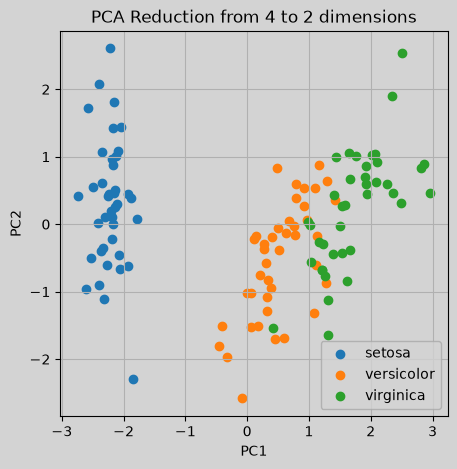

In [49]:
plt.figure(figsize=(5, 5), facecolor="lightgray")
plt.gca().set_facecolor("lightgray")

for i, target_name in enumerate(data.target_names):
    plt.scatter(
        X_train_pca[y_train == i, 0],
        X_train_pca[y_train == i, 1],
        label=target_name,
    )
plt.legend(loc="best", facecolor="lightgray", edgecolor="darkgray")
plt.title("PCA Reduction from 4 to 2 dimensions")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

Let's use a more complex dataset. We find that it is difficult to decide the number of pcs.

In [51]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### How to pick the number of PCs:
1. set `n_components` to a **float**. That tells sklearn to add PCs until it sums up to an explained variance ratio equal to this float.

In [ ]:
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Initial number of features: {X.shape[1]}")
print(f"Number of PCs: {len(pca.explained_variance_ratio_)}")
print(f"Information preserved per component: {pca.explained_variance_ratio_}")
print(f"Total information preserved: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Initial number of features: 30
Number of PCs: 10
Information preserved per component: [0.43502782 0.19500007 0.09781519 0.06486409 0.05253378 0.041128
 0.0223559  0.01647952 0.01380052 0.01205262]
Total information preserved: 95.11%


2. scree plot - **elbow method**: leave `n_components` as None. Sklearn creates PCs equal to the number of features. Plot the sum of variance and check for an elbow. During the process we can find the number the first method uses.

Number of PCs for explained variance ratio more than 95%: 10


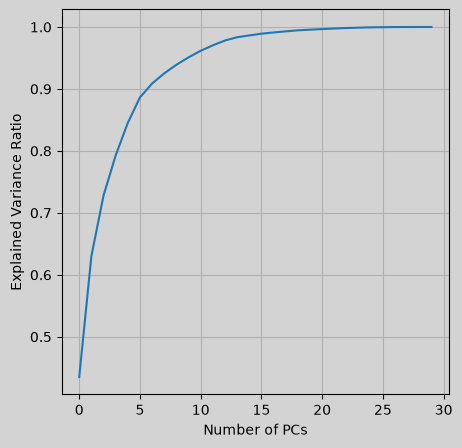

In [62]:
pca = PCA(random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

cumsum = np.cumsum(pca.explained_variance_ratio_)

d = np.argmax(cumsum >= 0.95) + 1
print(f"Number of PCs for explained variance ratio more than 95%: {d}")

plt.figure(figsize=(5, 5), facecolor="lightgray")
plt.gca().set_facecolor("lightgray")

plt.plot(cumsum)
plt.xlabel("Number of PCs")
plt.ylabel("Explained Variance Ratio")
plt.grid()
plt.show()

### PCA Compression

PCA reduces the dimensions but it also capable of returning a recreated version of the original information. A nice example is the mnist dataset. It recreates the image but with lower quality since it looses some information.

In [88]:
data = fetch_openml("mnist_784", version=1)

X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Initial number of features: 784
Number of PCs: 332


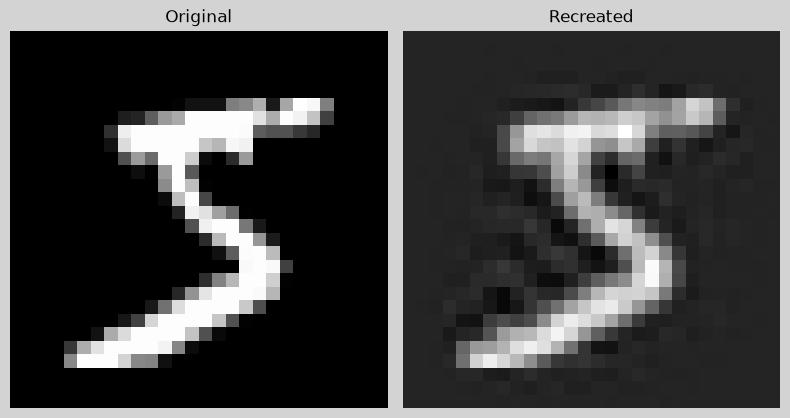

In [90]:
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
X_recreated = pca.inverse_transform(X_pca)
X_recreated = scaler.inverse_transform(X_recreated)

original_image = np.array(X.iloc[0, :]).reshape(28, 28)
recreated_image = X_recreated[0].reshape(28, 28)

print(f"Initial number of features: {X.shape[1]}")
print(f"Number of PCs: {len(pca.explained_variance_ratio_)}")

fig, (ax1, ax2) = plt.subplots(1, 2, facecolor="lightgray", figsize=(8, 14))

ax1.imshow(original_image, cmap="gray")
ax1.set_title("Original")
ax1.axis("off")

ax2.imshow(recreated_image, cmap="gray")
ax2.set_title("Recreated")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Incremental PCA

PCA requires the whole dataset loaded in ram. For large datasets that is a problem. In that case, `IncrementalPCA` can be used to be trained on batches.

In [ ]:
n_batches = 100
inc_pca = IncrementalPCA(n_components=332)  # 332 is the result from above
for X_batch in np.array_split(X_scaled, n_batches):
    inc_pca.partial_fit(X_batch)

X_pca = inc_pca.transform(X_scaled)

### Kernel PCA

In case the data is not linearly separable we can use the kernel trick. The right kernel can only be found using grid search. Popular kernels are `rbf`, `sigmoid` and `polynomial`. Sklearn implements this with `KernelPCA` class.

When to use Kernel PCA:
- when too many PCs (~80% of original dimensions) are needed to capture explained variance ratio of 90%.
- poor model performance, especially for simple models like logistic regression
- domain knowledge tells that the relationships are not linear. e.g. movement, bioinformatics, image and sound.

## Locally Linear Embedding - LLE

Powerful algorithm for non linear dimensionality reduction. PCA tries to find the maximum distances in order to preserve the maximum variance. LLE instead tries to maintain local relationships. 

How it works: 
1. It assumes that near a data instance the "neighbourhood" is linearly separable. 
2. It finds the k nearest neighbors
3. Expresses the point as a linear combination of its neighbors
4. Embeds the points in a lower dimension space, mantaining the calculated weights of step 3.

Hyperparameters:
- `n_neighbors`: k from step 2
- `n_components`: number of embedding dimensions

Sensitive to outliers

### PCA or LLE?

**PCA** should always be the **first choice**.

Use PCA when:
- linear relationships in the dataset
- need to reduce overfit or training time
- huge dataset (it works for small ones too)
- stability for new data

Use LLE when:
- manifold inside the data
- local relationships are very important
- small or medium and clean dataset

#### Should we chain dimensionality reduction algorithms?

Yes! A common example is using PCA to quickly get rid of a large number of useless dimensions, then applying another much slower dimensionality reduction algorithm, such as LLE. This two-step approach will likely yield the same performance as using LLE only, but in a fraction of the time.